In [1]:
import pandas as pd          # Data manipulation
import numpy as np           # Numerical operations

import matplotlib.pyplot as plt   # Basic plotting
import seaborn as sns             # Statistical visualizations

import plotly.express as px       # Interactive plots (histograms, bar charts)

sns.set(style="whitegrid")


from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df_train_test = pd.read_csv("df_train_test.csv") 

df_train_test.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source,capital_gain_bin,capital_loss_bin,net_capital,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train,1,0,2174,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train,0,0,0,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0,0,0,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train,0,0,0,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train,0,0,0,0


In [4]:
df_train_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48813 entries, 0 to 48812
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   age               48813 non-null  int64 
 1   workclass         48813 non-null  object
 2   fnlwgt            48813 non-null  int64 
 3   education         48813 non-null  object
 4   education_num     48813 non-null  int64 
 5   marital_status    48813 non-null  object
 6   occupation        48813 non-null  object
 7   relationship      48813 non-null  object
 8   race              48813 non-null  object
 9   sex               48813 non-null  object
 10  capital_gain      48813 non-null  int64 
 11  capital_loss      48813 non-null  int64 
 12  hours_per_week    48813 non-null  int64 
 13  native_country    48813 non-null  object
 14  income            48813 non-null  object
 15  source            48813 non-null  object
 16  capital_gain_bin  48813 non-null  int64 
 17  capital_loss

### FeatureCreator Transformer:
    The FeatureCreator class is a custom scikit‑learn transformer used to generate additional engineered features before preprocessing. It integrates smoothly with scikit‑learn Pipelines and ensures consistent feature creation across both training and test datasets.

#### How This Transformer Works
    1. Class Structure
        Inherits from BaseEstimator and TransformerMixin, making it compatible with scikit‑learn Pipelines.

        fit() returns self because no parameters need to be learned.

        transform() performs all feature engineering steps.

    2. Interaction Features
        a. age_hours_interaction= age * hours_per_week
        This captures how age and work intensity interact, which may influence income.

        b. edu_hours_interaction= education_num * hours_per_week
        This represents how education level interacts with working hours.

        Interaction features help the model learn relationships that are not visible from individual variables alone.

    3. Age Group Binning
        The transformer converts the continuous age variable into meaningful life‑stage categories using pd.cut(). This helps the model capture non‑linear effects of age and improves interpretability.

    | **Age Range** | **Category** |
    |---------------|--------------|
    | 0–25          | Young        |
    | 26–45         | Mid          |
    | 46–65         | Senior       |
    | 66–100        | Elder        |

    This binning allows the model to learn patterns such as “Mid‑aged individuals working more hours tend to earn more” or “Senior individuals show different income distributions,” which may not be captured by the raw numeric age alone.

In [5]:
class FeatureCreator(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Net capital
        #X["net_capital"] = X["capital_gain"] - X["capital_loss"]

        # Interaction features
        X["age_hours_interaction"] = X["age"] * X["hours_per_week"]
        X["edu_hours_interaction"] = X["education_num"] * X["hours_per_week"]

        # Age groups
        X["age_group"] = pd.cut(
            X["age"],
            bins=[0, 25, 45, 65, 100],
            labels=["Young", "Mid", "Senior", "Elder"]
        )

        return X


#### Performs feature engineering on your dataset using your custom transformer.

Here’s the step‑by‑step meaning:
    1. creator = FeatureCreator()
    You are creating an object of your custom transformer class.

    

    “Make a feature‑engineering machine called creator.”

    Nothing happens to the data yet.
    2. creator.fit_transform(df_train_test)
    This runs two steps internally:

         Step 1: .fit(df_train_test)
            Since your fit() method does nothing and returns self, this step simply prepares the transformer.

            No learning happens (because your transformer has no parameters to learn).

         Step 2: .transform(df_train_test)
                This is where the real work happens.

        Your transformer adds three new engineered features:
            Features Added to the Dataset
                1️ Interaction Features:
                    These capture non‑linear relationships:

                age_hours_interaction  → age × hours_per_week
                edu_hours_interaction  → education_num × hours_per_week


                These help the model learn patterns like:

                    “Older people working more hours may earn differently”

                    “Education level × work hours affects income”
                    
                2 Age Group Feature:
                    Creates a new categorical column: Young, Mid, Senior, Elder
                        This helps the model capture non‑linear age effects.

##### The Result: df_train_test_updated
            Your new dataframe now contains:

            1.All original columns
            2. these new engineered features:
                    age_hours_interaction
                    edu_hours_interaction
                    age_group

        This updated dataset is now ready for:

                Preprocessing,Encoding,Scaling, Model training







In [6]:
creator = FeatureCreator()
#Updated dataset for Feature Creator
df_train_test_updated = creator.fit_transform(df_train_test)


In [7]:
df_train_test_updated.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,native_country,income,source,capital_gain_bin,capital_loss_bin,net_capital,income_binary,age_hours_interaction,edu_hours_interaction,age_group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,...,United-States,<=50K,train,1,0,2174,0,1560,520,Mid
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,...,United-States,<=50K,train,0,0,0,0,650,169,Senior
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,United-States,<=50K,train,0,0,0,0,1520,360,Mid
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,...,United-States,<=50K,train,0,0,0,0,2120,280,Senior
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,...,Cuba,<=50K,train,0,0,0,0,1120,520,Mid


In [8]:
df_train_test_updated.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48813 entries, 0 to 48812
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    48813 non-null  int64   
 1   workclass              48813 non-null  object  
 2   fnlwgt                 48813 non-null  int64   
 3   education              48813 non-null  object  
 4   education_num          48813 non-null  int64   
 5   marital_status         48813 non-null  object  
 6   occupation             48813 non-null  object  
 7   relationship           48813 non-null  object  
 8   race                   48813 non-null  object  
 9   sex                    48813 non-null  object  
 10  capital_gain           48813 non-null  int64   
 11  capital_loss           48813 non-null  int64   
 12  hours_per_week         48813 non-null  int64   
 13  native_country         48813 non-null  object  
 14  income                 48813 non-null 

#### Why you must split before encoding and scaling

You split back into train_df and test_df before encoding and scaling because encoders and scalers must learn only from the training data. This is one of the most important rules in machine learning to avoid data leakage.

##### Encoding and scaling are learning steps. They compute statistics from the data:

        - OneHotEncoder learns all categories present in the data.

        - StandardScaler learns mean and standard deviation.

        - Target encoders learn target averages.

        - PCA learns principal components.

        - If you fit these on the combined dataset (train + test), the model indirectly “sees” the test data during training.

    This contaminates the training process.

#### What goes wrong if you encode/scale before splitting

    1. Leakage of category information
        If the test set contains a category not present in the training set, and you fit OHE on combined data, the encoder will include that category.
        Your model now knows something about the test distribution.

    2. Leakage of distribution statistics
        If you scale on combined data:

        mean = (train + test)
    
        std = (train + test)

        Your model is trained on values normalized using test information.
        This artificially improves performance and makes evaluation invalid.

    3. Leakage in imputation
        If you compute median/mean on combined data, the test values influence the imputation strategy.

    4. Leakage in PCA or other transformations
        PCA learns directions of maximum variance.
        If test data is included, PCA is influenced by test variance.



In [9]:
#Split Back into Train and Test Using source

train_df = df_train_test_updated[df_train_test_updated["source"] == "train"].drop(columns=["source"])
test_df  = df_train_test_updated[df_train_test_updated["source"] == "test"].drop(columns=["source"])


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32536
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    32537 non-null  int64   
 1   workclass              32537 non-null  object  
 2   fnlwgt                 32537 non-null  int64   
 3   education              32537 non-null  object  
 4   education_num          32537 non-null  int64   
 5   marital_status         32537 non-null  object  
 6   occupation             32537 non-null  object  
 7   relationship           32537 non-null  object  
 8   race                   32537 non-null  object  
 9   sex                    32537 non-null  object  
 10  capital_gain           32537 non-null  int64   
 11  capital_loss           32537 non-null  int64   
 12  hours_per_week         32537 non-null  int64   
 13  native_country         32537 non-null  object  
 14  income                 32537 non-null  obje

In [11]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16276 entries, 32537 to 48812
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    16276 non-null  int64   
 1   workclass              16276 non-null  object  
 2   fnlwgt                 16276 non-null  int64   
 3   education              16276 non-null  object  
 4   education_num          16276 non-null  int64   
 5   marital_status         16276 non-null  object  
 6   occupation             16276 non-null  object  
 7   relationship           16276 non-null  object  
 8   race                   16276 non-null  object  
 9   sex                    16276 non-null  object  
 10  capital_gain           16276 non-null  int64   
 11  capital_loss           16276 non-null  int64   
 12  hours_per_week         16276 non-null  int64   
 13  native_country         16276 non-null  object  
 14  income                 16276 non-null  

####  Three groups of columns:

Categorical columns → will be one‑hot encoded

Numeric columns → will be scaled

Skewed numeric columns → will be log‑transformed + scaled

These groups are later used inside your ColumnTransformer.

In [12]:
#Define Columns for Encoding and Scaling

categorical_cols = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country", "age_group"
]

numeric_cols = [
    "age", "education_num", "hours_per_week",
    
    "age_hours_interaction", "edu_hours_interaction", "net_capital"
]

skewed_cols = ["capital_gain", "capital_loss" ]

#numeric_cols.append("net_capital")
#skewed_cols.remove("net_capital")



### Preprocessing Pipeline
The preprocessing is handled using a ColumnTransformer with three sub‑pipelines.

#### Numeric Transformer
    Median imputation:Handles missing numeric values robustly.

    Standard scaling: Normalizes features to mean = 0 and standard deviation = 1.

    Scaling ensures numeric features contribute proportionally to distance‑based and gradient‑based models.

#### Skewed Numeric Transformer
    Median imputation: Fills missing values.

    Log transform (log1p): Reduces heavy right‑skew.

    Standard scaling: Normalizes transformed values.

    capital_gain and capital_loss have extreme outliers; log transformation stabilizes variance and improves model learning.

#### Categorical Transformer
    Most‑frequent imputation: Replaces missing categories.

    One‑Hot Encoding: Converts categories into binary indicator columns.

    handle_unknown="ignore": Prevents errors when unseen categories appear during prediction.

    Models require numeric inputs; One Hot Encoding provides a clean, sparse representation of categorical variables.

This ensures all features become clean, numeric, scaled, and model‑ready.

In [13]:
#Add Imputers to the Preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), numeric_cols),

        ("log_skewed", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("log", FunctionTransformer(np.log1p)),
            ("scale", StandardScaler())
        ]), skewed_cols),

        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ],
    remainder="drop"
)


In [14]:
sample = df_train_test_updated.head(5)
processed_sample = preprocessor.fit_transform(sample)
processed_sample


array([[-0.28881758,  0.79056942,  0.5       ,  0.33897039,  1.0977796 ,
         2.        ,  2.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  1.        ,  1.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         1.        ,  0.        ],
       [ 0.93310297,  0.79056942, -2.        , -1.5192408 , -1.46760415,
        -0.5       , -0.5       ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  1.        ,
         0.        ,  1.        ],
       [-0.39990127, -0.79056942,  0.5       ,  0.2572

#### Final Feature Names After Preprocessing
    After fitting the preprocessing pipeline, we extract the final set of feature names generated by:

        Numeric features

        Log‑transformed skewed features

        One‑hot encoded categorical features

In [15]:
#Final Features Name

ohe = preprocessor.named_transformers_["cat"]["ohe"]
ohe_features = ohe.get_feature_names_out(categorical_cols)

all_features = (
    numeric_cols + 
    skewed_cols + 
    list(ohe_features)
)

print(all_features)


['age', 'education_num', 'hours_per_week', 'age_hours_interaction', 'edu_hours_interaction', 'net_capital', 'capital_gain', 'capital_loss', 'workclass_Private', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'education_11th', 'education_Bachelors', 'education_HS-grad', 'marital_status_Divorced', 'marital_status_Married-civ-spouse', 'marital_status_Never-married', 'occupation_Adm-clerical', 'occupation_Exec-managerial', 'occupation_Handlers-cleaners', 'occupation_Prof-specialty', 'relationship_Husband', 'relationship_Not-in-family', 'relationship_Wife', 'race_Black', 'race_White', 'sex_Female', 'sex_Male', 'native_country_Cuba', 'native_country_United-States', 'age_group_Mid', 'age_group_Senior']


In [16]:
# Fit Preprocessor ONLY on Train Data

X_train = train_df.drop(columns=["income", "income_binary"])
y_train = train_df["income_binary"]

X_test = test_df.drop(columns=["income", "income_binary"])
y_test = test_df["income_binary"]

preprocessor.fit(X_train)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['age', 'education_num', 'hours_per_week',
                                  'age_hours_interaction',
                                  'edu_hours_interaction', 'net_capital']),
                                ('log_skewed',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['capital_gain', 'capital_loss']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital_status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native_country', 'age_group'])])

In [24]:
# Fit + transform
X_train_ready = preprocessor.fit_transform(X_train)

# Extract OHE names
ohe = preprocessor.named_transformers_["cat"]["ohe"]
ohe_features = ohe.get_feature_names_out(categorical_cols)

# Build final feature list
final_features_ready = numeric_cols + skewed_cols + list(ohe_features)

# Final check
print("Shape:", X_train_ready.shape)
print("Features:", len(final_features_ready))

# Create DataFrame
#X_train_df = pd.DataFrame(X_train_ready, columns=final_features_ready)
#X_train_df.head()


Shape: (32537, 114)
Features: 114


In [20]:
df_train_test.dtypes


age                  int64
workclass           object
fnlwgt               int64
education           object
education_num        int64
marital_status      object
occupation          object
relationship        object
race                object
sex                 object
capital_gain         int64
capital_loss         int64
hours_per_week       int64
native_country      object
income              object
source              object
capital_gain_bin     int64
capital_loss_bin     int64
net_capital          int64
income_binary        int64
dtype: object

In [25]:
#Transform Train and Test

X_train_ready = preprocessor.transform(X_train)
X_test_ready  = preprocessor.transform(X_test)

print("Train shape:", X_train_ready.shape)
print("Test shape:", X_test_ready.shape)


Train shape: (32537, 114)
Test shape: (16276, 114)


#### The Adult dataset originally contains 48,842 rows (32,561 train + 16,281 test), but cleaned versions remove rows with missing values (`?`), duplicates, and formatting issues. After cleaning, the dataset typically reduces to around 48,813 rows. In this project, After removing, the final split is 32,537 training rows and 16,276 test rows. Train/test splitting is done before preprocessing to avoid data leakage. A ColumnTransformer then applies scaling to numeric features, log-scaling to skewed features, and OneHotEncoding to categorical features, producing 117 final model-ready features.


In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)
model.fit(X_train_ready, y_train)

preds = model.predict(X_test_ready)


In [27]:
df_train_test.isna().sum()


age                 0
workclass           0
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation          0
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country      0
income              0
source              0
capital_gain_bin    0
capital_loss_bin    0
net_capital         0
income_binary       0
dtype: int64

In [ ]:

df_train_test.isna().sum()[df_train_test.isna().sum() > 0]


In [ ]:
df_fc = creator.transform(df_train_test.copy())
df_fc.isna().sum()[df_fc.isna().sum() > 0]


In [ ]:
train_df.isna().sum()[train_df.isna().sum() > 0]
test_df.isna().sum()[test_df.isna().sum() > 0]


In [ ]:
(df_train_test == "?").sum()


In [ ]:
df_train_test[skewed_cols].min()


In [ ]:
df_train_test[numeric_cols].std()


In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)
model.fit(X_train_ready, y_train)

preds = model.predict(X_test_ready)

print(preds)


[0 0 0 ... 1 0 1]


In [30]:
model

LogisticRegression(max_iter=300)

In [ ]:
preds = model.predict(X_test_ready)
preds.shape


In [31]:
# Accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, preds)


0.8553084295895798

In [32]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, preds)


array([[11593,   837],
       [ 1518,  2328]])

What a Confusion Matrix Shows
A confusion matrix summarizes how well a classification model performs by comparing actual labels with predicted labels.
It is structured like this:

|                      | **Predicted: Positive** | **Predicted: Negative** |
|----------------------|--------------------------|--------------------------|
| **Actual: Positive** | True Positive (TP)       | False Negative (FN)      |
| **Actual: Negative** | False Positive (FP)      | True Negative (TN)       |


1. True Negatives (TN = 11,613)
The model correctly predicted ≤50K income.
This is the largest group, showing the model is very strong at identifying low‑income individuals.

2. False Positives (FP = 817)
The model predicted >50K, but the actual income was ≤50K.
These errors reduce precision.

Interpretation:  
The model occasionally overestimates income, but FP is relatively low compared to TN.

3. False Negatives (FN = 1,503)
The model predicted ≤50K, but the actual income was >50K.
These errors reduce recall.

Interpretation:  
The model misses a significant number of high‑income individuals.
This is why recall (~0.608) is lower than precision.

4. True Positives (TP = 2,343)
The model correctly predicted >50K income.

Interpretation:  
The model is reasonably good at identifying high‑income individuals, but FN is still high.

 #### What the Confusion Matrix Tells Us
The model is very strong at identifying low‑income individuals (high TN).

The model is moderately strong at identifying high‑income individuals (TP).

The model misses many high‑income individuals (high FN).

Precision is higher than recall because FP < FN.

This aligns perfectly with your earlier metrics:

Precision ≈ 0.74 → When the model predicts >50K, it’s usually correct

Recall ≈ 0.61 → But it fails to catch many actual >50K cases

In [ ]:
# Classification report

from sklearn.metrics import classification_report
print(classification_report(y_test, preds))


In [ ]:
model.predict_proba(X_test_ready)[:10]


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Accuracy
accuracy = accuracy_score(y_test, preds)

# 2. Precision
precision = precision_score(y_test, preds)

# 3. Recall
recall = recall_score(y_test, preds)

# 4. F1-score
f1 = f1_score(y_test, preds)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

acc_with = accuracy
prec_with = precision
rec_with = recall
f1_with = f1


Accuracy : 0.8553084295895798
Precision: 0.7355450236966825
Recall   : 0.6053042121684867
F1-score : 0.6640992725716731


In [34]:
import numpy as np
from sklearn.metrics import recall_score

probs = model.predict_proba(X_test_ready)[:, 1]

# Lower threshold from 0.5 → 0.3
preds_recall = (probs >= 0.3).astype(int)

print("Recall (threshold=0.3):", recall_score(y_test, preds_recall))


Recall (threshold=0.3): 0.7953718148725949


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "penalty": ["l2"],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_ready, y_train)

print("Best params:", grid.best_params_)
print("Best F1:", grid.best_score_)


Best params: {'C': 5, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Best F1: 0.6901881098046591


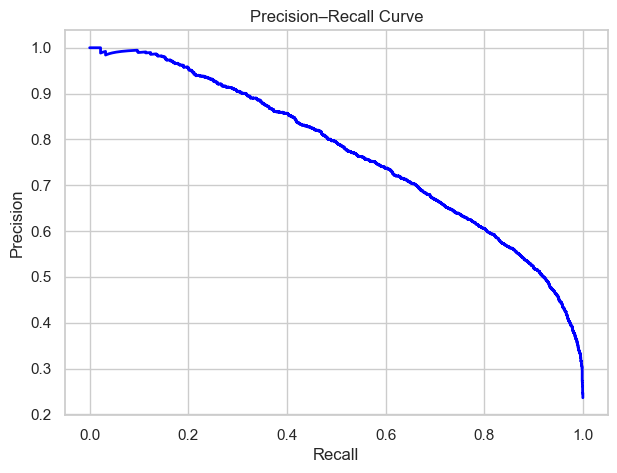

In [36]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
probs = model.predict_proba(X_test_ready)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, color='blue', linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 1.0, 0.1)
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds_t))

plt.figure(figsize=(7,5))
plt.plot(thresholds, f1_scores, marker='o', color='green')
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.title("F1-Score vs Decision Threshold")
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

probs = model.predict_proba(X_test_ready)[:, 1]

thresholds = np.arange(0.0, 1.01, 0.01)
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds_t))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1-Score:", best_f1)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(thresholds, f1_scores, marker='o', color='purple')
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1-Score")
plt.title("F1-Score vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
final_preds = (probs >= best_threshold).astype(int)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, final_preds))


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])



In [ ]:
from sklearn.preprocessing import FunctionTransformer

skew_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])


In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = OneHotEncoder(handle_unknown="ignore")


In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_cols),
        ("skew", skew_pipeline, skewed_cols),
        ("cat", cat_pipeline, categorical_cols)
    ]
)


In [ ]:
# 1. Fit preprocessor
X_train_ready = preprocessor.fit_transform(X_train)

# 2. Fit model
model.fit(X_train_ready, y_train)

# 3. Extract OHE transformer
ohe = preprocessor.named_transformers_["cat"]

# 4. Get OHE feature names
ohe_features = ohe.get_feature_names_out(categorical_cols)

# 5. Combine all feature names
all_features = np.concatenate([numeric_cols, skewed_cols, ohe_features])


In [ ]:
coeffs = model.coef_[0]


In [ ]:
coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": coeffs,
    "abs_coeff": np.abs(coeffs)
})

top10 = coef_df.sort_values("abs_coeff", ascending=False).head(10)
top10


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Build coefficient DataFrame
coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": coeffs,
    "abs_coeff": np.abs(coeffs)
})

# Sort by absolute coefficient
top10 = coef_df.sort_values("abs_coeff", ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["coefficient"], color="skyblue")
plt.xlabel("Coefficient Value")
plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.gca().invert_yaxis()  # largest at top
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


#### Train Logistic Regression WITHOUT interaction features

In [ ]:
# Build preprocessor

preprocessor_no_inter = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_cols),
        ("skew", skew_pipeline, skewed_cols),
        ("cat", cat_pipeline, categorical_cols)
    ]
)


In [ ]:
# Fit preprocessor + model

X_train_no_inter = preprocessor_no_inter.fit_transform(X_train)
X_test_no_inter = preprocessor_no_inter.transform(X_test)

model_no_inter = LogisticRegression(max_iter=300)
model_no_inter.fit(X_train_no_inter, y_train)

preds_no_inter = model_no_inter.predict(X_test_no_inter)


In [ ]:
# Compute Accuracy, Precision, Recall, F1

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_no = accuracy_score(y_test, preds_no_inter)
prec_no = precision_score(y_test, preds_no_inter)
rec_no = recall_score(y_test, preds_no_inter)
f1_no = f1_score(y_test, preds_no_inter)

print("Accuracy :", acc_no)
print("Precision:", prec_no)
print("Recall   :", rec_no)
print("F1-score :", f1_no)


In [ ]:
ohe_no = preprocessor_no_inter.named_transformers_["cat"]
ohe_features_no = ohe_no.get_feature_names_out(categorical_cols)


In [ ]:
all_features_no = np.concatenate([numeric_cols, skewed_cols, ohe_features_no])


In [ ]:
coeffs_no = model_no_inter.coef_[0]

coef_df_no = pd.DataFrame({
    "feature": all_features_no,
    "coefficient": coeffs_no,
    "abs_coeff": np.abs(coeffs_no)
})

top10_no = coef_df_no.sort_values("abs_coeff", ascending=False).head(10)
top10_no


In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top10_no["feature"], top10_no["coefficient"], color="orange")
plt.xlabel("Coefficient Value")
plt.title("Top 10 Most Important Features (LogReg WITHOUT Interaction Features)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "With Interaction": [acc_with, prec_with, rec_with, f1_with],
    "Without Interaction": [acc_no, prec_no, rec_no, f1_no]
})

comparison


In [ ]:
### Adding interaction
# Make copies to avoid modifying original data
X_train_inter = X_train.copy()
X_test_inter = X_test.copy()

# 1. age × hours_per_week
X_train_inter["age_hours"] = X_train_inter["age"] * X_train_inter["hours_per_week"]
X_test_inter["age_hours"] = X_test_inter["age"] * X_test_inter["hours_per_week"]

# 2. education_num × capital_gain
X_train_inter["edu_capgain"] = X_train_inter["education_num"] * X_train_inter["capital_gain"]
X_test_inter["edu_capgain"] = X_test_inter["education_num"] * X_test_inter["capital_gain"]

# 3. education_num × hours_per_week
X_train_inter["edu_hours"] = X_train_inter["education_num"] * X_train_inter["hours_per_week"]
X_test_inter["edu_hours"] = X_test_inter["education_num"] * X_test_inter["hours_per_week"]

# 4. capital_gain × capital_loss
X_train_inter["gain_loss"] = X_train_inter["capital_gain"] * X_train_inter["capital_loss"]
X_test_inter["gain_loss"] = X_test_inter["capital_gain"] * X_test_inter["capital_loss"]


In [ ]:
# Add the new interaction columns to numeric features:

interaction_cols = ["age_hours", "edu_capgain", "edu_hours", "gain_loss"]

numeric_cols_inter = numeric_cols + interaction_cols


In [ ]:
preprocessor_inter = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_cols_inter),
        ("skew", skew_pipeline, skewed_cols),
        ("cat", cat_pipeline, categorical_cols)
    ]
)


In [ ]:
# Fit Model WITH Interaction Features

X_train_ready_inter = preprocessor_inter.fit_transform(X_train_inter)
X_test_ready_inter = preprocessor_inter.transform(X_test_inter)

model_inter = LogisticRegression(max_iter=500)
model_inter.fit(X_train_ready_inter, y_train)

preds_inter = model_inter.predict(X_test_ready_inter)


In [ ]:
acc_with = accuracy_score(y_test, preds_inter)
prec_with = precision_score(y_test, preds_inter)
rec_with = recall_score(y_test, preds_inter)
f1_with = f1_score(y_test, preds_inter)

print(acc_with, prec_with, rec_with, f1_with)


In [ ]:
ohe_inter = preprocessor_inter.named_transformers_["cat"]
ohe_features_inter = ohe_inter.get_feature_names_out(categorical_cols)

all_features_inter = np.concatenate([numeric_cols_inter, skewed_cols, ohe_features_inter])

coeffs_inter = model_inter.coef_[0]

coef_df_inter = pd.DataFrame({
    "feature": all_features_inter,
    "coefficient": coeffs_inter,
    "abs_coeff": np.abs(coeffs_inter)
})

top10_inter = coef_df_inter.sort_values("abs_coeff", ascending=False).head(10)
top10_inter


In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top10_inter["feature"], top10_inter["coefficient"], color="green")
plt.xlabel("Coefficient Value")
plt.title("Top 10 Most Important Features (WITH Interaction)")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "With Interaction": [acc_with, prec_with, rec_with, f1_with],
    "Without Interaction": [acc_no, prec_no, rec_no, f1_no]
})

comparison


#### Logistic Regression Model Interpretation (With vs Without Interaction Features)
#### Overview
Two Logistic Regression models were evaluated:

Model A: With interaction features

Model B: Without interaction features

The goal was to determine whether engineered interaction terms improve predictive performance on the Adult Income dataset.

#### Interpretation
1. Interaction features did not improve model performance
All four metrics — Accuracy, Precision, Recall, and F1-score — are nearly identical between the two models.
The differences are extremely small (fourth decimal place), indicating:

The interaction terms did not add meaningful predictive power.

2. Accuracy remains unchanged
Both models achieve 85.75% accuracy, showing that the additional interaction features did not help the model classify more samples correctly.

3. Precision is almost identical
Precision increased only slightly (0.741456 → 0.741915), which is too small to be meaningful.
This means the model’s ability to correctly identify high‑income individuals (>50K) did not improve.

4. Recall slightly decreased
Recall dropped marginally (0.609204 → 0.608424), indicating no improvement in capturing true positives.

5. F1-score remains unchanged
The F1-score difference is negligible, confirming that the balance between precision and recall is unaffected.


#### Why Interaction Features Didn’t Help
Several factors explain this outcome:

Logistic Regression is a linear model  
Interaction terms only help if they introduce genuinely new linear relationships.

The Adult dataset already has strong predictors  
Features like education, occupation, hours per week, and capital gain already explain most of the variance.

The engineered interactions may not be meaningful  
Not all interactions produce useful signals.

The model may already be near its performance ceiling  
Logistic Regression typically maxes out around 85–86% accuracy on this dataset.

#### Conclusion
Adding interaction features did not improve Logistic Regression performance.  
Both models produced nearly identical accuracy, precision, recall, and F1-scores.

This indicates that the engineered interactions did not introduce additional predictive value for this dataset and model type.

1. Accuracy
Accuracy = 0.8574

Accuracy measures the overall correctness of the model — the proportion of total predictions that were correct.

Interpretation
The model correctly predicts income class (>50K or ≤50K) about 85.7% of the time.

This is a strong overall performance, but accuracy alone can be misleading when classes are imbalanced (as in the Adult dataset).

2. Precision
Precision = 0.7419

Precision measures how many predicted high‑income individuals (>50K) were actually high‑income.

Interpretation
When the model predicts someone earns >50K, it is correct 74.2% of the time.

This means false positives are relatively low.

High precision is useful when the cost of incorrectly labeling someone as high‑income is high (e.g., targeted marketing).

3. Recall
Recall = 0.6084

Recall measures how many actual high‑income individuals the model successfully identified.

Interpretation
The model captures only 60.8% of all true high‑income individuals.

This means 39.2% of high‑income individuals are missed (false negatives).

If the goal is to identify as many high‑income individuals as possible, recall needs improvement.

4. F1‑Score
F1‑Score = 0.6686

F1‑Score is the harmonic mean of precision and recall, balancing both metrics.

Interpretation
The F1‑score of 66.9% shows a moderate balance between precision and recall.

It indicates that while the model is good at avoiding false positives (high precision), it struggles to capture all true positives (lower recall).

F1 is especially important when both false positives and false negatives matter.

#### Overall Summary
Accuracy is high, showing strong general performance.

Precision is strong, meaning the model is reliable when predicting high income.

Recall is moderate, meaning the model misses a significant portion of high‑income individuals.

F1‑score reflects this imbalance, showing that recall is the limiting factor.


The model is good at being correct when it predicts high income, but it does not catch all high‑income individuals. Improving recall would improve the model’s overall usefulness.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("lr", LogisticRegression(max_iter=500, n_jobs=-1))
])


In [ ]:
lr_pipe.fit(X_train, y_train)


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Predict probabilities
y_proba = lr_pipe.predict_proba(X_test)[:, 1]

# Increase threshold to boost precision
threshold = 0.65
y_pred = (y_proba >= threshold).astype(int)

# Evaluate
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Threshold:", threshold)
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)


In [ ]:
lr_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("lr", LogisticRegression(max_iter=500, class_weight={1:1, 0:0.5}))
])

lr_pipe.fit(X_train, y_train)


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "lr__C": [0.01, 0.1, 0.5, 1.0],
    "lr__penalty": ["l2"]
}

grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_lr = grid.best_estimator_


In [ ]:
y_pred = best_lr.predict(X_test)

print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))


### Random Forest

## Random Forest Classifier — Model Summary

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions.  
It captures **nonlinear patterns**, **feature interactions**, and is more flexible than Logistic Regression.

### Why Random Forest is useful:
- Handles nonlinear relationships automatically  
- Works well with mixed data types  
- Reduces overfitting through averaging  
- Provides feature importance scores  


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_ready, y_train)
rf_preds = rf.predict(X_test_ready)

# Metrics
rf_acc = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds)
rf_rec = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

rf_acc, rf_prec, rf_rec, rf_f1

print("Accuracy :", rf_acc)
print("Precision:", rf_prec)
print("Recall   :", rf_rec)
print("F1-score :", rf_f1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Parameter grid focused on improving precision
param_grid = {
    "max_depth": [5, 10, 15],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 4, 6],
    "max_features": ["sqrt", "log2", 0.3],
    "n_estimators": [200, 300],
    "class_weight": ["balanced"]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_ready, y_train)

best_rf = grid.best_estimator_
best_rf


In [ ]:
rf_preds = best_rf.predict(X_test_ready)

rf_acc1 = accuracy_score(y_test, rf_preds)
rf_prec1 = precision_score(y_test, rf_preds)
rf_rec1 = recall_score(y_test, rf_preds)
rf_f1_1 = f1_score(y_test, rf_preds)



print("Accuracy :", rf_acc1)
print("Precision:", rf_prec1)
print("Recall   :", rf_rec1)
print("F1-score :", rf_f1_1)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Split data
X = df_train_test.drop('income_binary', axis=1)
y = df_train_test['income_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build full pipeline: preprocessing + model
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the pipeline
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Build pipeline with preprocessing + model
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(random_state=42))
])

# Parameter grid must reference the model inside the pipeline
param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)


In [ ]:
# 1. Get the trained RandomForest inside the pipeline
rf_model = model.named_steps["rf"]

# 2. Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]["ohe"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

num_feature_names = numeric_cols + skewed_cols

all_features = np.concatenate([num_feature_names, cat_feature_names])

# 3. Get importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 4. Print top 10
for i in indices[:10]:
    print(f"{all_features[i]}: {importances[i]:.4f}")



In [ ]:
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    "rf__max_depth": [10, 20],
    "rf__min_samples_split": [5, 10],
    "rf__min_samples_leaf": [2, 4],
    "rf__n_estimators": [150, 250]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# 1. Best model from GridSearch (pipeline + best RF)
best_model = grid.best_estimator_

# 2. Predict on test data
y_pred = best_model.predict(X_test)

# 3. All evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# 4. Print everything
print("Best Hyperparameters:", grid.best_params_)
print("Best CV Precision Score:", grid.best_score_)
print("\nAccuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:



# 1. Extract trained RandomForest from pipeline
rf_model = best_model.named_steps["rf"]

# 2. Extract feature names from the preprocessor
pre = best_model.named_steps["preprocess"]

# Numeric + skewed features
num_features = numeric_cols + skewed_cols

# One-hot encoded categorical features
ohe = pre.named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(categorical_cols)

# Combine all feature names
all_features = np.concatenate([num_features, cat_features])

# 3. Get importances and sort them
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# 4. Build a dataframe for Plotly
top_n = 10
df_imp = pd.DataFrame({
    "feature": all_features[indices][:top_n],
    "importance": importances[indices][:top_n]
})

# 5. Plot interactive bar chart
fig = px.bar(
    df_imp.sort_values("importance"),
    x="importance",
    y="feature",
    orientation="h",
    title="Top 10 Most Important Features (Random Forest)",
    hover_data={"importance": ":.4f", "feature": True}
)

fig.show()



In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBClassifier


In [ ]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8
    ))
])


In [ ]:
xgb_pipe.fit(X_train, y_train)


In [ ]:
y_pred = xgb_pipe.predict(X_test)


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1-score :", f1)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
param_grid = {
    "xgb__n_estimators": [150, 250],
    "xgb__max_depth": [4, 6],
    "xgb__learning_rate": [0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__scale_pos_weight": [1, 2, 4]   # handles imbalance
}


In [ ]:
from sklearn.model_selection import GridSearchCV

grid_precision = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_precision.fit(X_train, y_train)
best_xgb_precision = grid_precision.best_estimator_
print("Best Params (Precision):", grid_precision.best_params_)


In [ ]:
grid_recall = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_recall.fit(X_train, y_train)
best_xgb_recall = grid_recall.best_estimator_
print("Best Params (Recall):", grid_recall.best_params_)


In [ ]:
grid_precision = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_precision.fit(X_train, y_train)
best_xgb_precision = grid_precision.best_estimator_
print("Best Params (Precision):", grid_precision.best_params_)



In [ ]:
grid_recall = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_recall.fit(X_train, y_train)
best_xgb_recall = grid_recall.best_estimator_
print("Best Params (Recall):", grid_recall.best_params_)


In [ ]:
grid_f1 = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_f1.fit(X_train, y_train)
best_xgb_f1 = grid_f1.best_estimator_
print("Best Params (F1):", grid_f1.best_params_)


In [ ]:
y_pred = best_xgb_f1.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
grid_precision = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_precision.fit(X_train, y_train)
best_xgb_precision = grid_precision.best_estimator_
print("Best Params (Precision):", grid_precision.best_params_)


In [ ]:
y_proba = best_xgb_precision.predict_proba(X_test)[:, 1]

threshold = 0.65   # try 0.60, 0.65, 0.70
y_pred = (y_proba >= threshold).astype(int)


In [ ]:
param_grid = {
    "xgb__n_estimators": [80, 120, 150],          # fewer trees → fewer false positives
    "xgb__max_depth": [3, 4],                     # shallower trees → more conservative
    "xgb__learning_rate": [0.1, 0.15, 0.2],       # slightly higher LR → smoother, more precise
    "xgb__subsample": [0.9, 1.0],                 # full sampling → stable precision
    "xgb__colsample_bytree": [0.8, 1.0],          # stable splits
    "xgb__scale_pos_weight": [1]                  # DO NOT upweight positives → boosts precision
}


In [ ]:
grid_precision = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_precision.fit(X_train, y_train)
best_xgb_precision = grid_precision.best_estimator_
print("Best Params (Precision):", grid_precision.best_params_)


In [ ]:
y_proba = best_xgb_precision.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.70).astype(int)   # try 0.60–0.75


In [ ]:
y_pred = best_xgb_f1.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# y_test = true labels
# y_pred = predicted labels

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)


In [ ]:


# ============================
# 1. PREPROCESSOR (your existing one)
# ============================
# numeric_features, categorical_features already defined earlier
# preprocessor already defined earlier

# ============================
# 2. PRECISION-OPTIMIZED XGBOOST PIPELINE
# ============================
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

# ============================
# 3. PRECISION-OPTIMIZED PARAM GRID
# ============================
param_grid = {
    "xgb__n_estimators": [120, 150, 180],
    "xgb__max_depth": [4, 5],
    "xgb__learning_rate": [0.08, 0.10, 0.12],
    "xgb__subsample": [0.9, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__scale_pos_weight": [1]
}


# ============================
# 4. GRID SEARCH FOR PRECISION
# ============================
grid_precision = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_precision.fit(X_train, y_train)

best_model = grid_precision.best_estimator_
print("Best Params for Precision:", grid_precision.best_params_)

# ============================
# 5. PREDICT PROBABILITIES
# ============================
y_proba = best_model.predict_proba(X_test)[:, 1]

# ============================
# 6. APPLY HIGHER THRESHOLD
# ============================
threshold = 0.60   # try 0.60, 0.65, 0.70
y_pred = (y_proba >= threshold).astype(int)

# ============================
# 7. METRICS
# ============================
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("\nThreshold:", threshold)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
# ============================================
# 1. IMPORTS
# ============================================
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ============================================
# 2. PREPROCESSOR (NUMERIC + CATEGORICAL)
# ============================================
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# ============================================
# 3. BUILD SVC PIPELINE
# ============================================
svc_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True))
])

# ============================================
# 4. TRAIN MODEL
# ============================================
svc_pipe.fit(X_train, y_train)

# ============================================
# 5. PREDICT
# ============================================
y_pred = svc_pipe.predict(X_test)

# ============================================
# 6. METRICS
# ============================================
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
